# Análise do Mercado Publicitário Audiovisual — ANCINE

## Sobre o projeto

Este projeto realiza uma análise exploratória de dados públicos da Agência Nacional do Cinema (ANCINE), utilizando informações sobre obras audiovisuais publicitárias registradas por meio do Certificado de Registro de Título (CRT), agentes econômicos regulares e suas atividades econômicas.

O objetivo é explorar características do mercado publicitário audiovisual brasileiro, identificando padrões relacionados ao volume de registros, segmentos de mercado, tipos de publicidade e agentes envolvidos.

### Bases utilizadas

- Obras Publicitárias — CRT
- Agentes Econômicos Regulares
- Atividades Econômicas dos Agentes Regulares

Os dados são preparados e analisados em Python utilizando Pandas e Matplotlib.

## 1. Importação das bibliotecas

In [26]:
import pandas as pd
import numpy as np

## 2. Carregamento e consolidação dos dados

In [27]:
from pathlib import Path

pasta_projeto = Path("..")

caminho_crt = pasta_projeto / "data" / "crt_obras_publicitarias"
caminho_agentes = pasta_projeto / "data" / "agentes-economicos-regulares.csv"
caminho_atividades = pasta_projeto / "data" / "atividades-economicas-agentes-regulares.csv"

print("Pasta CRT:", caminho_crt.exists())
print("Agentes:", caminho_agentes.exists())
print("Atividades:", caminho_atividades.exists())

Pasta CRT: True
Agentes: True
Atividades: True


In [28]:
agentes = pd.read_csv(
    caminho_agentes,
    sep=";",
    encoding="utf-8",
    low_memory=False
)

atividades = pd.read_csv(
    caminho_atividades,
    sep=";",
    encoding="utf-8",
    low_memory=False
)

# Localiza todos os arquivos do CRT
arquivos_crt = sorted(caminho_crt.glob("*.csv"))

print(f"Arquivos CRT encontrados: {len(arquivos_crt)}")
print(f"Registros em Agentes: {len(agentes)}")
print(f"Registros em Atividades: {len(atividades)}")

Arquivos CRT encontrados: 164
Registros em Agentes: 18884
Registros em Atividades: 147288


## 3. Validação inicial das bases

Nesta etapa, são verificadas a estrutura, a dimensão e a integridade inicial das bases utilizadas no projeto. Como os dados de obras publicitárias são disponibilizados em múltiplos arquivos CSV, também é validada a consistência estrutural desses arquivos antes das análises.

In [29]:
from collections import Counter

print("--- REVALIDAÇÃO DO CRT ---")

total_linhas = 0
todos_crts = []
estruturas = {}
arquivos_vazios = []
arquivos_com_erro = []

for arquivo in arquivos_crt:
    try:
        df_temp = pd.read_csv(
            arquivo,
            sep=";",
            encoding="utf-8",
            low_memory=False
        )

        # Quantidade de registros
        total_linhas += len(df_temp)

        # Arquivos vazios
        if len(df_temp) == 0:
            arquivos_vazios.append(arquivo.name)

        # CRTs
        if "CRT" in df_temp.columns:
            todos_crts.extend(
                df_temp["CRT"].dropna().astype(str)
            )

        # Estruturas de colunas
        colunas = tuple(df_temp.columns)

        if colunas not in estruturas:
            estruturas[colunas] = []

        estruturas[colunas].append(arquivo.name)

    except Exception as erro:
        arquivos_com_erro.append((arquivo.name, str(erro)))

contagem_crts = Counter(todos_crts)

crts_repetidos = {
    crt: quantidade
    for crt, quantidade in contagem_crts.items()
    if quantidade > 1
}

print(f"Arquivos analisados: {len(arquivos_crt)}")
print(f"Total de linhas: {total_linhas}")
print(f"CRTs únicos: {len(contagem_crts)}")
print(f"CRTs repetidos: {len(crts_repetidos)}")
print(f"Estruturas diferentes: {len(estruturas)}")
print(f"Arquivos vazios: {len(arquivos_vazios)}")
print(f"Arquivos com erro: {len(arquivos_com_erro)}")

print("\nDetalhamento das estruturas:")

for numero, (colunas, arquivos) in enumerate(estruturas.items(), start=1):
    print(
        f"Estrutura {numero}: "
        f"{len(arquivos)} arquivos | "
        f"{len(colunas)} colunas"
    )

--- REVALIDAÇÃO DO CRT ---
Arquivos analisados: 164
Total de linhas: 560295
CRTs únicos: 535494
CRTs repetidos: 14886
Estruturas diferentes: 1
Arquivos vazios: 0
Arquivos com erro: 0

Detalhamento das estruturas:
Estrutura 1: 164 arquivos | 25 colunas


### Resultado da validação

Foram analisados 164 arquivos CSV de obras publicitárias, todos com a mesma estrutura de 25 colunas. Não foram identificados arquivos vazios nem erros de leitura.

Após a consolidação, foram contabilizados 560.295 registros e 535.494 CRTs únicos. Também foram identificados 14.886 CRTs presentes em mais de um registro.

Como a repetição de um código de CRT não significa necessariamente que os registros sejam duplicados, essas ocorrências são analisadas a seguir antes de qualquer decisão de tratamento.

##  4. Investigação de CRTs repetidos

Como foram identificados CRTs presentes em mais de um registro, esta etapa verifica se essas ocorrências representam linhas duplicadas ou registros distintos associados ao mesmo CRT.

In [30]:
crt = pd.concat(
    [
        pd.read_csv(
            arquivo,
            sep=";",
            encoding="utf-8",
            low_memory=False
        )
        for arquivo in arquivos_crt
    ],
    ignore_index=True
)

print(f"Linhas consolidadas: {len(crt)}")
print(f"CRTs únicos: {crt['CRT'].nunique()}")


duplicatas_exatas = crt.duplicated().sum()


mascara_crt_repetido = crt["CRT"].duplicated(keep=False)
linhas_crt_repetido = crt[mascara_crt_repetido]

print(f"Linhas totalmente duplicadas: {duplicatas_exatas}")
print(f"Linhas pertencentes a CRTs repetidos: {len(linhas_crt_repetido)}")

Linhas consolidadas: 560295
CRTs únicos: 535494
Linhas totalmente duplicadas: 0
Linhas pertencentes a CRTs repetidos: 39687


#### Resultado da investigação

A base consolidada possui 560.295 registros e 535.494 CRTs únicos. Não foram identificadas linhas totalmente duplicadas.

Entretanto, 39.687 registros pertencem a CRTs que aparecem mais de uma vez. Como não se tratam de duplicatas exatas, é necessário verificar quais informações variam entre os registros associados ao mesmo CRT antes de definir qualquer tratamento.

Por esse motivo, os registros repetidos não são removidos automaticamente.

## 4.1 Campos com variação entre CRTs repetidos

Para compreender a origem das repetições, são comparados os campos dos registros associados ao mesmo CRT, identificando quais informações apresentam valores diferentes.

In [31]:
print("--- DIFERENÇAS ENTRE CRTs REPETIDOS ---")

colunas_com_variacao = {}

for coluna in crt.columns:
    if coluna == "CRT":
        continue

    variacao = (
        linhas_crt_repetido
        .groupby("CRT")[coluna]
        .nunique(dropna=False)
    )

    quantidade = (variacao > 1).sum()

    if quantidade > 0:
        colunas_com_variacao[coluna] = quantidade

resultado_variacao = (
    pd.Series(colunas_com_variacao)
    .sort_values(ascending=False)
)

print(resultado_variacao)

--- DIFERENÇAS ENTRE CRTs REPETIDOS ---
DIRETOR                       6852
PRODUTOR                      3921
CNPJ_ANUNCIANTE               3241
ANUNCIANTE                    2811
CNPJ_AGENCIA                  1224
AGENCIA                       1149
REQUERENTE                       1
REGISTRO_ANCINE_REQUERENTE       1
CNPJ_REQUERENTE                  1
UF_REQUERENTE                    1
MUNICIPIO_REQUERENTE             1
dtype: int64


In [32]:
exemplos_crt = (
    linhas_crt_repetido["CRT"]
    .value_counts()
    .head(5)
    .index
)

colunas_exemplo = [
    "CRT",
    "TITULO_ORIGINAL",
    "DIRETOR",
    "PRODUTOR",
    "ANUNCIANTE",
    "CNPJ_ANUNCIANTE",
    "AGENCIA",
    "CNPJ_AGENCIA",
    "REQUERENTE",
    "CNPJ_REQUERENTE"
]

exemplos = (
    crt[crt["CRT"].isin(exemplos_crt)]
    [colunas_exemplo]
    .sort_values("CRT")
)

exemplos

,CRT,TITULO_ORIGINAL,DIRETOR,PRODUTOR,ANUNCIANTE,CNPJ_ANUNCIANTE,AGENCIA,CNPJ_AGENCIA,REQUERENTE,CNPJ_REQUERENTE
331459,20200372470001,ESQUENTA BLACK A,ELIEL QUARESMA DE MOURA,DVDUPLI VIDEO PRODUCOES LTDA,SENDAS DISTRIBUIDORA S/A,06.057.223/0342-38,BETC HAVAS AGENCIA DE PUBLICIDADE LTDA.,19.555.578/0001-32,DVDUPLI VIDEO PRODUCOES LTDA,06.865.469/0001-70
331460,20200372470001,ESQUENTA BLACK A,ELIEL QUARESMA DE MOURA,DVDUPLI VIDEO PRODUCOES LTDA,SENDAS DISTRIBUIDORA S/A,06.057.223/0355-52,BETC HAVAS AGENCIA DE PUBLICIDADE LTDA.,19.555.578/0001-32,DVDUPLI VIDEO PRODUCOES LTDA,06.865.469/0001-70
331461,20200372470001,ESQUENTA BLACK A,ELIEL QUARESMA DE MOURA,DVDUPLI VIDEO PRODUCOES LTDA,SENDAS DISTRIBUIDORA S/A,06.057.223/0361-09,BETC HAVAS AGENCIA DE PUBLICIDADE LTDA.,19.555.578/0001-32,DVDUPLI VIDEO PRODUCOES LTDA,06.865.469/0001-70
331462,20200372470001,ESQUENTA BLACK A,ELIEL QUARESMA DE MOURA,DVDUPLI VIDEO PRODUCOES LTDA,SENDAS DISTRIBUIDORA S/A,06.057.223/0367-96,BETC HAVAS AGENCIA DE PUBLICIDADE LTDA.,19.555.578/0001-32,DVDUPLI VIDEO PRODUCOES LTDA,06.865.469/0001-70
331463,20200372470001,ESQUENTA BLACK A,ELIEL QUARESMA DE MOURA,DVDUPLI VIDEO PRODUCOES LTDA,SENDAS DISTRIBUIDORA S/A,06.057.223/0371-72,BETC HAVAS AGENCIA DE PUBLICIDADE LTDA.,19.555.578/0001-32,DVDUPLI VIDEO PRODUCOES LTDA,06.865.469/0001-70
...,...,...,...,...,...,...,...,...,...,...
336506,20200395770001,NATAL,ELIEL QUARESMA DE MOURA,DVDUPLI VIDEO PRODUCOES LTDA,SENDAS DISTRIBUIDORA S/A,06.057.223/0310-50,BETC HAVAS AGENCIA DE PUBLICIDADE LTDA.,19.555.578/0001-32,DVDUPLI VIDEO PRODUCOES LTDA,06.865.469/0001-70
336507,20200395770001,NATAL,ELIEL QUARESMA DE MOURA,DVDUPLI VIDEO PRODUCOES LTDA,SENDAS DISTRIBUIDORA S/A,06.057.223/0309-17,BETC HAVAS AGENCIA DE PUBLICIDADE LTDA.,19.555.578/0001-32,DVDUPLI VIDEO PRODUCOES LTDA,06.865.469/0001-70
336508,20200395770001,NATAL,ELIEL QUARESMA DE MOURA,DVDUPLI VIDEO PRODUCOES LTDA,SENDAS DISTRIBUIDORA S/A,06.057.223/0308-36,BETC HAVAS AGENCIA DE PUBLICIDADE LTDA.,19.555.578/0001-32,DVDUPLI VIDEO PRODUCOES LTDA,06.865.469/0001-70
336509,20200395770001,NATAL,ELIEL QUARESMA DE MOURA,DVDUPLI VIDEO PRODUCOES LTDA,SENDAS DISTRIBUIDORA S/A,06.057.223/0306-74,BETC HAVAS AGENCIA DE PUBLICIDADE LTDA.,19.555.578/0001-32,DVDUPLI VIDEO PRODUCOES LTDA,06.865.469/0001-70


### Interpretação

A análise confirma que os registros associados ao mesmo CRT não representam duplicatas exatas. As principais variações ocorrem nos campos de diretor, produtor, anunciante e agência, e os exemplos analisados mostram diferentes informações associadas a um mesmo código de CRT.

Por esse motivo, os registros não serão removidos com base apenas na repetição do CRT. Nas análises relacionadas à quantidade de obras registradas será utilizada a contagem de CRTs únicos, enquanto os registros completos serão preservados nas análises que dependam das informações associadas às obras.

## 5. Qualidade e preparação dos dados

Nesta etapa, são avaliados valores ausentes, tipos de dados e possíveis inconsistências presentes na base consolidada. O objetivo é definir tratamentos adequados e preparar os dados para as análises exploratórias, preservando informações válidas e evitando alterações sem justificativa.

## 5.1 Estrutura e tipos de dados

Inicialmente, são verificados os tipos de dados e a quantidade de valores preenchidos em cada coluna da base consolidada.

In [33]:
print("--- INFORMAÇÕES DO CRT ---")
crt.info()

--- INFORMAÇÕES DO CRT ---
<class 'pandas.DataFrame'>
RangeIndex: 560295 entries, 0 to 560294
Data columns (total 25 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   TITULO_ORIGINAL             560295 non-null  str    
 1   CRT                         560295 non-null  int64  
 2   DATA_REQUERIMENTO_CRT       560295 non-null  str    
 3   DATA_EMISSAO_CRT            559806 non-null  str    
 4   DATA_VALIDADE_CRT           560295 non-null  str    
 5   SITUACAO_CRT                560295 non-null  str    
 6   PAIS                        32949 non-null   object 
 7   PRODUTO_SERVICO_ANUNCIADO   560294 non-null  str    
 8   TIPO_PUBLICIDADE            560295 non-null  str    
 9   QTD_VERSOES                 337962 non-null  float64
 10  CRTS_VERSOES                338166 non-null  str    
 11  CLASSIFICACAO_OBRA          560295 non-null  str    
 12  SEGMENTO                    560295 non-null  str    
 13

## 5.2 Valores ausentes

A quantidade e o percentual de valores ausentes são analisados para identificar campos que exigem atenção durante a preparação dos dados.

In [34]:
ausentes_crt = pd.DataFrame({
    "ausentes": crt.isna().sum(),
    "percentual": (crt.isna().mean() * 100).round(2)
})

ausentes_crt = (
    ausentes_crt
    .sort_values("percentual", ascending=False)
)

ausentes_crt

,ausentes,percentual
PAIS,527346,94.12
QTD_VERSOES,222333,39.68
CRTS_VERSOES,222129,39.65
AGENCIA,185360,33.08
PRODUTOR,31641,5.65
DIRETOR,24608,4.39
DATA_EMISSAO_CRT,489,0.09
DATA_REQUERIMENTO_CRT,0,0.00
TITULO_ORIGINAL,0,0.00
TIPO_PUBLICIDADE,0,0.00


## 5.3 Verificação de valores categóricos

Além dos valores ausentes reconhecidos pelo Pandas, alguns campos categóricos podem conter textos que representam situações específicas ou ausência de informação. Por isso, são examinados os valores mais frequentes das principais colunas categóricas.

In [35]:
colunas_categoricas = [
    "PAIS",
    "AGENCIA",
    "CNPJ_AGENCIA",
    "ANUNCIANTE",
    "CNPJ_ANUNCIANTE",
    "PRODUTOR",
    "DIRETOR",
    "REQUERENTE",
    "CNPJ_REQUERENTE"
]

for coluna in colunas_categoricas:
    print(f"\n--- {coluna} ---")
    print(crt[coluna].value_counts(dropna=False).head(10))


--- PAIS ---
PAIS
NaN               527346
BRASIL             24635
ESTADOS UNIDOS      3030
REINO UNIDO          798
ARGENTINA            632
FRANCA               510
ESPANHA              386
CORÉIA DO SUL        318
PARAGUAI             277
URUGUAI              268
Name: count, dtype: int64

--- AGENCIA ---
AGENCIA
NaN                                            185360
L.R DINIZ PROPAGANDA LTDA                       11042
OFICINA DE COMUNICACAO LTDA. - EPP               6096
BETC HAVAS AGENCIA DE PUBLICIDADE LTDA.          4670
MC CANN ERICKSON PUBLICIDADE LIMITADA            3802
AFRICA DDB BRASIL PUBLICIDADE LTDA.              3676
ALMAP BBDO PUBLICIDADE E COMUNICACOES LTDA.      3139
PUBLICIS BRASIL COMUNICACAO LTDA                 3074
EXIT COMUNICACAO ESTRATEGICA LTDA - EPP          2966
LEO BURNETT PUBLICIDADE LTDA.                    2842
Name: count, dtype: int64

--- CNPJ_AGENCIA ---
CNPJ_AGENCIA
NÃO INFORMADO         185362
07.054.028/0001-50     11042
02.852.456/0001-05   

## 5.4 Padronização das datas

As colunas relacionadas às datas de requerimento, emissão e validade do CRT são convertidas para o formato de data, garantindo a padronização necessária para as análises temporais.

In [36]:
colunas_data = [
    "DATA_REQUERIMENTO_CRT",
    "DATA_EMISSAO_CRT",
    "DATA_VALIDADE_CRT"
]

for coluna in colunas_data:
    crt[coluna] = pd.to_datetime(
        crt[coluna],
        errors="coerce",
        dayfirst=True
    )

print(crt[colunas_data].dtypes)

DATA_REQUERIMENTO_CRT    datetime64[us]
DATA_EMISSAO_CRT         datetime64[us]
DATA_VALIDADE_CRT        datetime64[us]
dtype: object


In [37]:
print("Valores ausentes após conversão:")

for coluna in colunas_data:
    print(f"{coluna}: {crt[coluna].isna().sum()}")

Valores ausentes após conversão:
DATA_REQUERIMENTO_CRT: 0
DATA_EMISSAO_CRT: 489
DATA_VALIDADE_CRT: 0


## 5.5 Verificação das variáveis numéricas

As variáveis `DURACAO_SEGUNDOS` e `QTD_VERSOES` são analisadas por meio de estatísticas descritivas e da verificação de valores extremos, com o objetivo de identificar possíveis inconsistências antes das análises exploratórias.

In [38]:
print("--- ESTATÍSTICAS DAS VARIÁVEIS NUMÉRICAS ---")

crt[
    ["DURACAO_SEGUNDOS", "QTD_VERSOES"]
].describe()

--- ESTATÍSTICAS DAS VARIÁVEIS NUMÉRICAS ---


,DURACAO_SEGUNDOS,QTD_VERSOES
count,560295.000000,337962.000000
mean,125.897477,14.877155
std,2597.223203,19.600923
min,0.000000,1.000000
25%,15.000000,5.000000
50%,30.000000,5.000000
75%,30.000000,10.000000
max,86400.000000,999.000000


In [39]:
print("Duração igual ou menor que zero:")
print((crt["DURACAO_SEGUNDOS"] <= 0).sum())

print("\nQuantidade de versões igual ou menor que zero:")
print((crt["QTD_VERSOES"] <= 0).sum())

print("\nMaiores durações encontradas:")
print(
    crt["DURACAO_SEGUNDOS"]
    .sort_values(ascending=False)
    .head(10)
    .to_list()
)

print("\nMaiores quantidades de versões encontradas:")
print(
    crt["QTD_VERSOES"]
    .dropna()
    .sort_values(ascending=False)
    .head(10)
    .to_list()
)

Duração igual ou menor que zero:
27

Quantidade de versões igual ou menor que zero:
0

Maiores durações encontradas:
[86400, 86400, 86400, 86400, 86400, 86400, 86400, 86400, 86400, 86400]

Maiores quantidades de versões encontradas:
[999.0, 580.0, 550.0, 501.0, 501.0, 501.0, 501.0, 500.0, 500.0, 500.0]


In [40]:
colunas_extremos = [
    "CRT",
    "TITULO_ORIGINAL",
    "TIPO_PUBLICIDADE",
    "CLASSIFICACAO_OBRA",
    "SEGMENTO",
    "DURACAO_SEGUNDOS",
    "QTD_VERSOES"
]

crt.nlargest(
    20,
    "DURACAO_SEGUNDOS"
)[colunas_extremos]

,CRT,TITULO_ORIGINAL,TIPO_PUBLICIDADE,CLASSIFICACAO_OBRA,SEGMENTO,DURACAO_SEGUNDOS,QTD_VERSOES
4698,20130095130008,KOLLING GRILL,PERÍODO DE 24HS INSERIDO EM CANAL TELEVENDA / ...,OBRA AUDIOVISUAL PUBLICITÁRIA BRASILEIRA FILMA...,TODOS OS SEGMENTOS DE MERCADO,86400,5.0
7120,20130108370007,FEIRÃO LIRAMOTO,PERÍODO DE 24HS INSERIDO EM CANAL TELEVENDA / ...,OBRA AUDIOVISUAL PUBLICITÁRIA BRASILEIRA FILMA...,RADIODIFUSÃO DE SONS E IMAGENS (TV ABERTA),86400,NaN
17937,20130273480000,EXPOENTE,PERÍODO DE 24HS INSERIDO EM CANAL TELEVENDA / ...,OBRA AUDIOVISUAL PUBLICITÁRIA ESTRANGEIRA,RADIODIFUSÃO DE SONS E IMAGENS (TV ABERTA),86400,NaN
19654,20130275760000,JORGE E MATEUS AÇAILÂNDIA,PERÍODO DE 24HS INSERIDO EM CANAL TELEVENDA / ...,OBRA AUDIOVISUAL PUBLICITÁRIA ESTRANGEIRA,RADIODIFUSÃO DE SONS E IMAGENS (TV ABERTA),86400,NaN
29511,20130285510006,VT SHOW,PERÍODO DE 24HS INSERIDO EM CANAL TELEVENDA / ...,OBRA AUDIOVISUAL PUBLICITÁRIA ESTRANGEIRA,RADIODIFUSÃO DE SONS E IMAGENS (TV ABERTA),86400,NaN
35989,20130377400002,GUIA LOCAL SETEMBRO 2013,TELEVENDA / INFOMERCIAL,OBRA AUDIOVISUAL PUBLICITÁRIA BRASILEIRA FILMA...,COMUNICAÇÃO ELETRÔNICA DE MASSA POR ASSINATURA...,86400,NaN
40724,20130426130000,GUIA LOCAL OUTUBRO 2013,TELEVENDA / INFOMERCIAL,OBRA AUDIOVISUAL PUBLICITÁRIA BRASILEIRA FILMA...,COMUNICAÇÃO ELETRÔNICA DE MASSA POR ASSINATURA...,86400,NaN
45328,20130499290007,GUIA LOCAL DEZEMBRO 2013,TELEVENDA / INFOMERCIAL,OBRA AUDIOVISUAL PUBLICITÁRIA BRASILEIRA FILMA...,COMUNICAÇÃO ELETRÔNICA DE MASSA POR ASSINATURA...,86400,NaN
45329,20130466490007,GUIA LOCAL NOVEMBRO 2013,TELEVENDA / INFOMERCIAL,OBRA AUDIOVISUAL PUBLICITÁRIA BRASILEIRA FILMA...,COMUNICAÇÃO ELETRÔNICA DE MASSA POR ASSINATURA...,86400,NaN
45491,20130476810004,INSTITUCIONAL 2013,PERÍODO DE 24HS INSERIDO EM CANAL TELEVENDA / ...,OBRA AUDIOVISUAL PUBLICITÁRIA BRASILEIRA FILMA...,RADIODIFUSÃO DE SONS E IMAGENS (TV ABERTA),86400,NaN


In [41]:
crt[
    crt["DURACAO_SEGUNDOS"] == 0
][colunas_extremos]

,CRT,TITULO_ORIGINAL,TIPO_PUBLICIDADE,CLASSIFICACAO_OBRA,SEGMENTO,DURACAO_SEGUNDOS,QTD_VERSOES
30,20130022500000,ALBA JANEIRO 01,COMUM,OBRA AUDIOVISUAL PUBLICITÁRIA BRASILEIRA FILMA...,RADIODIFUSÃO DE SONS E IMAGENS (TV ABERTA),0,5.0
58,20130019270007,Alerta Cofrana,COMUM,OBRA AUDIOVISUAL PUBLICITÁRIA BRASILEIRA FILMA...,RADIODIFUSÃO DE SONS E IMAGENS (TV ABERTA),0,NaN
192,20130014960005,CELEBRAÇÃO 2013,COMUM,OBRA AUDIOVISUAL PUBLICITÁRIA BRASILEIRA FILMA...,RADIODIFUSÃO DE SONS E IMAGENS (TV ABERTA),0,NaN
228,20130000950002,CONSORCIO 2013,COMUM,OBRA AUDIOVISUAL PUBLICITÁRIA BRASILEIRA FILMA...,OUTROS MERCADOS,0,NaN
293,20130017100007,Classic Janeiro,COMUM,OBRA AUDIOVISUAL PUBLICITÁRIA BRASILEIRA FILMA...,RADIODIFUSÃO DE SONS E IMAGENS (TV ABERTA),0,NaN
346,20130020580006,EAD LIVRO,COMUM,OBRA AUDIOVISUAL PUBLICITÁRIA BRASILEIRA FILMA...,RADIODIFUSÃO DE SONS E IMAGENS (TV ABERTA),0,NaN
352,20130017750001,ECOVALLEY OPÇÃO V2,COMUM,OBRA AUDIOVISUAL PUBLICITÁRIA BRASILEIRA FILMA...,RADIODIFUSÃO DE SONS E IMAGENS (TV ABERTA),0,NaN
365,20130005710000,EU AJUDO,COMUM,OBRA AUDIOVISUAL PUBLICITÁRIA BRASILEIRA FILMA...,RADIODIFUSÃO DE SONS E IMAGENS (TV ABERTA),0,NaN
386,20130001580004,FESTIVAL DE SEMI-NOVOS,TELEVENDA / INFOMERCIAL,OBRA AUDIOVISUAL PUBLICITÁRIA BRASILEIRA FILMA...,RADIODIFUSÃO DE SONS E IMAGENS (TV ABERTA),0,NaN
618,20130006980000,LUZIANIA IPTU 2013 1,COMUM,OBRA AUDIOVISUAL PUBLICITÁRIA BRASILEIRA FILMA...,RADIODIFUSÃO DE SONS E IMAGENS (TV ABERTA),0,NaN


In [42]:
crt.nlargest(
    20,
    "QTD_VERSOES"
)[colunas_extremos]

,CRT,TITULO_ORIGINAL,TIPO_PUBLICIDADE,CLASSIFICACAO_OBRA,SEGMENTO,DURACAO_SEGUNDOS,QTD_VERSOES
305071,20200043590007,OFERTAS CAMPEÃO,COMUM,OBRA AUDIOVISUAL PUBLICITÁRIA BRASILEIRA FILMA...,RADIODIFUSÃO DE SONS E IMAGENS (TV ABERTA),15,999.0
141659,20160079860005,MACACO NOÉ,COMUM,OBRA AUDIOVISUAL PUBLICITÁRIA BRASILEIRA FILMA...,RADIODIFUSÃO DE SONS E IMAGENS (TV ABERTA),15,580.0
330636,20200385450004,BLACK WEEK R,TELEVENDA / INFOMERCIAL,OBRA AUDIOVISUAL PUBLICITÁRIA BRASILEIRA FILMA...,TODOS OS SEGMENTOS DE MERCADO,30,550.0
33422,20130311340001,TORRA CTBA,COMUM,OBRA AUDIOVISUAL PUBLICITÁRIA BRASILEIRA FILMA...,RADIODIFUSÃO DE SONS E IMAGENS (TV ABERTA),30,501.0
107314,20150251790006,NOVOTEMPO,COMUM,OBRA AUDIOVISUAL PUBLICITÁRIA BRASILEIRA FILMA...,RADIODIFUSÃO DE SONS E IMAGENS (TV ABERTA),30,501.0
301994,20200001610000,MOMENTO SAÚDE,COMUM,OBRA AUDIOVISUAL PUBLICITÁRIA BRASILEIRA FILMA...,RADIODIFUSÃO DE SONS E IMAGENS (TV ABERTA),45,501.0
395585,20220193900001,ARCOMIXSOL25,COMUM,OBRA AUDIOVISUAL PUBLICITÁRIA BRASILEIRA FILMA...,TODOS OS SEGMENTOS DE MERCADO,30,501.0
300677,20200024320008,ALAGOAS MOTOS,COMUM,OBRA AUDIOVISUAL PUBLICITÁRIA BRASILEIRA FILMA...,RADIODIFUSÃO DE SONS E IMAGENS (TV ABERTA),30,500.0
458975,20230455280005,CREDISIS - CQR,COMUM,OBRA AUDIOVISUAL PUBLICITÁRIA BRASILEIRA FILMA...,RADIODIFUSÃO DE SONS E IMAGENS (TV ABERTA),30,500.0
468082,20240096820007,CQR - FAMILIA,COMUM,OBRA AUDIOVISUAL PUBLICITÁRIA BRASILEIRA FILMA...,RADIODIFUSÃO DE SONS E IMAGENS (TV ABERTA),30,500.0


## 5.6 Decisões de tratamento

A análise das variáveis numéricas indicou que os maiores valores de duração correspondem a registros de televenda ou infomerciais com duração de 24 horas, não havendo evidência de erro nesses casos. Por esse motivo, esses valores são mantidos.

Foram identificados 27 registros com duração igual a zero. Como esses valores podem representar inconsistências de preenchimento, eles serão preservados na base para as demais análises, mas excluídos especificamente das análises relacionadas à duração.

Os valores elevados de `QTD_VERSOES`, incluindo registros com centenas de versões, também foram inspecionados e não apresentaram evidências suficientes para serem considerados erros. Dessa forma, são mantidos na base.

Os valores ausentes não são preenchidos artificialmente quando não há informação confiável para substituição. Da mesma forma, valores categóricos como `PESSOA FÍSICA` são preservados como informação válida, enquanto registros textuais como `NÃO INFORMADO` são considerados ausência de informação no campo correspondente.

## 6. Validação do relacionamento entre as bases

Nesta etapa, é avaliada a possibilidade de integração entre os registros de obras publicitárias, os agentes econômicos regulares e suas respectivas atividades econômicas.

## 6.1 Identificação das chaves de relacionamento

São identificadas as colunas disponíveis nas três bases que podem ser utilizadas como chaves de integração, com atenção especial aos campos de CNPJ e Registro ANCINE.

In [43]:
print("--- CHAVES PARA RELACIONAMENTO ---")

print("\nCRT:")
print([
    coluna for coluna in crt.columns
    if "CNPJ" in coluna or "REGISTRO" in coluna
])

print("\nAgentes:")
print([
    coluna for coluna in agentes.columns
    if "CNPJ" in coluna or "REGISTRO" in coluna
])

print("\nAtividades:")
print([
    coluna for coluna in atividades.columns
    if "CNPJ" in coluna or "REGISTRO" in coluna
])

--- CHAVES PARA RELACIONAMENTO ---

CRT:
['CNPJ_AGENCIA', 'CNPJ_ANUNCIANTE', 'REGISTRO_ANCINE_REQUERENTE', 'CNPJ_REQUERENTE']

Agentes:
['REGISTRO_ANCINE', 'DATA_REGISTRO', 'CNPJ']

Atividades:
['REGISTRO_ANCINE', 'CNPJ']


## 6.2 Validação do relacionamento por CNPJ

O CNPJ do requerente é comparado ao CNPJ dos agentes econômicos para avaliar a cobertura do relacionamento entre as bases. Para permitir a comparação, os valores são padronizados mantendo apenas os dígitos e considerando como CNPJ válido os registros com 14 caracteres.

In [44]:
def limpar_cnpj(serie):
    return (
        serie
        .astype("string")
        .str.replace(r"\D", "", regex=True)
        .replace("", pd.NA)
    )

cnpj_crt = limpar_cnpj(crt["CNPJ_REQUERENTE"])
cnpj_agentes = limpar_cnpj(agentes["CNPJ"])
cnpj_atividades = limpar_cnpj(atividades["CNPJ"])

# Considera apenas CNPJs com 14 dígitos
cnpj_crt_valido = cnpj_crt[cnpj_crt.str.len() == 14]
cnpj_agentes_valido = cnpj_agentes[cnpj_agentes.str.len() == 14]
cnpj_atividades_valido = cnpj_atividades[cnpj_atividades.str.len() == 14]

set_agentes = set(cnpj_agentes_valido)
set_atividades = set(cnpj_atividades_valido)

print("--- COBERTURA POR CNPJ ---")

print(f"Registros CRT: {len(crt)}")
print(f"CRT com CNPJ válido: {len(cnpj_crt_valido)}")

encontrados_agentes = cnpj_crt_valido.isin(set_agentes).sum()

print(f"CRT encontrados em Agentes: {encontrados_agentes}")
print(
    f"Cobertura CRT → Agentes: "
    f"{encontrados_agentes / len(cnpj_crt_valido) * 100:.2f}%"
)

print(f"\nAgentes com CNPJ válido: {len(cnpj_agentes_valido)}")

encontrados_atividades = cnpj_agentes_valido.isin(set_atividades).sum()

print(f"Agentes encontrados em Atividades: {encontrados_atividades}")
print(
    f"Cobertura Agentes → Atividades: "
    f"{encontrados_atividades / len(cnpj_agentes_valido) * 100:.2f}%"
)

--- COBERTURA POR CNPJ ---
Registros CRT: 560295
CRT com CNPJ válido: 548964
CRT encontrados em Agentes: 398210
Cobertura CRT → Agentes: 72.54%

Agentes com CNPJ válido: 18884
Agentes encontrados em Atividades: 18884
Cobertura Agentes → Atividades: 100.00%


## 6.3 Validação do relacionamento por Registro ANCINE

Como alternativa ao CNPJ, também é avaliado o Registro ANCINE como possível chave de relacionamento entre as bases. Inicialmente, os valores são comparados em seu formato original para verificar a compatibilidade entre os campos.

In [45]:
print("--- COBERTURA POR REGISTRO ANCINE ---")

registro_crt = (
    crt["REGISTRO_ANCINE_REQUERENTE"]
    .astype("string")
    .str.strip()
)

registro_agentes = (
    agentes["REGISTRO_ANCINE"]
    .astype("string")
    .str.strip()
)

registro_atividades = (
    atividades["REGISTRO_ANCINE"]
    .astype("string")
    .str.strip()
)

# Remove valores ausentes
registro_crt_valido = registro_crt.dropna()
registro_agentes_valido = registro_agentes.dropna()
registro_atividades_valido = registro_atividades.dropna()

set_agentes_registro = set(registro_agentes_valido)
set_atividades_registro = set(registro_atividades_valido)

# CRT -> Agentes
encontrados_agentes_registro = (
    registro_crt_valido.isin(set_agentes_registro).sum()
)

print(f"Registros CRT: {len(crt)}")
print(
    f"CRT com Registro ANCINE preenchido: "
    f"{len(registro_crt_valido)}"
)
print(
    f"CRT encontrados em Agentes: "
    f"{encontrados_agentes_registro}"
)

if len(registro_crt_valido) > 0:
    print(
        f"Cobertura CRT → Agentes: "
        f"{encontrados_agentes_registro / len(registro_crt_valido) * 100:.2f}%"
    )

# Agentes -> Atividades
encontrados_atividades_registro = (
    registro_agentes_valido.isin(set_atividades_registro).sum()
)

print(
    f"\nAgentes com Registro ANCINE preenchido: "
    f"{len(registro_agentes_valido)}"
)
print(
    f"Agentes encontrados em Atividades: "
    f"{encontrados_atividades_registro}"
)

if len(registro_agentes_valido) > 0:
    print(
        f"Cobertura Agentes → Atividades: "
        f"{encontrados_atividades_registro / len(registro_agentes_valido) * 100:.2f}%"
    )

--- COBERTURA POR REGISTRO ANCINE ---
Registros CRT: 560295
CRT com Registro ANCINE preenchido: 560281
CRT encontrados em Agentes: 0
Cobertura CRT → Agentes: 0.00%

Agentes com Registro ANCINE preenchido: 18884
Agentes encontrados em Atividades: 18884
Cobertura Agentes → Atividades: 100.00%


## 6.4 Padronização do Registro ANCINE

A comparação inicial não identificou correspondências entre os registros. A inspeção dos valores revelou uma diferença de formatação: na base de CRT, os códigos podem apresentar o sufixo `.0`, enquanto na base de agentes são armazenados sem esse sufixo.

Por esse motivo, os campos são padronizados antes de uma nova validação do relacionamento.

In [46]:
print("--- EXEMPLOS DE REGISTRO ANCINE ---")

print("\nCRT:")
print(
    crt["REGISTRO_ANCINE_REQUERENTE"]
    .dropna()
    .astype(str)
    .head(20)
    .to_list()
)

print("\nAGENTES:")
print(
    agentes["REGISTRO_ANCINE"]
    .dropna()
    .astype(str)
    .head(20)
    .to_list()
)

print("\nATIVIDADES:")
print(
    atividades["REGISTRO_ANCINE"]
    .dropna()
    .astype(str)
    .head(20)
    .to_list()
)

--- EXEMPLOS DE REGISTRO ANCINE ---

CRT:
['18858.0', '18858.0', '18858.0', '16337.0', '20769.0', '4566.0', '4566.0', '19601.0', '18403.0', '3331.0', '3869.0', '3407.0', '12053.0', '20599.0', '3219.0', '3223.0', '17283.0', '3331.0', '18896.0', '7097.0']

AGENTES:
['59538', '32426', '52179', '57511', '23809', '24897', '60378', '44885', '62068', '63746', '44650', '56787', '13798', '349', '59135', '23394', '62314', '32643', '37338', '55915']

ATIVIDADES:
['59538', '59538', '59538', '59538', '59538', '59538', '59538', '59538', '59538', '59538', '59538', '59538', '32426', '32426', '32426', '32426', '32426', '32426', '32426', '32426']


In [47]:
print("--- COBERTURA POR REGISTRO ANCINE PADRONIZADO ---")

def limpar_registro_ancine(serie):
    return (
        serie
        .astype("string")
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
    )

registro_crt = limpar_registro_ancine(
    crt["REGISTRO_ANCINE_REQUERENTE"]
).dropna()

registro_agentes = limpar_registro_ancine(
    agentes["REGISTRO_ANCINE"]
).dropna()

registro_atividades = limpar_registro_ancine(
    atividades["REGISTRO_ANCINE"]
).dropna()

set_agentes_registro = set(registro_agentes)
set_atividades_registro = set(registro_atividades)

# CRT -> Agentes
encontrados_agentes_registro = registro_crt.isin(
    set_agentes_registro
).sum()

print(f"CRT com Registro ANCINE: {len(registro_crt)}")
print(f"CRT encontrados em Agentes: {encontrados_agentes_registro}")

print(
    f"Cobertura CRT → Agentes: "
    f"{encontrados_agentes_registro / len(registro_crt) * 100:.2f}%"
)

# Agentes -> Atividades
encontrados_atividades_registro = registro_agentes.isin(
    set_atividades_registro
).sum()

print(f"\nAgentes com Registro ANCINE: {len(registro_agentes)}")
print(
    f"Agentes encontrados em Atividades: "
    f"{encontrados_atividades_registro}"
)

print(
    f"Cobertura Agentes → Atividades: "
    f"{encontrados_atividades_registro / len(registro_agentes) * 100:.2f}%"
)

--- COBERTURA POR REGISTRO ANCINE PADRONIZADO ---
CRT com Registro ANCINE: 560281
CRT encontrados em Agentes: 398210
Cobertura CRT → Agentes: 71.07%

Agentes com Registro ANCINE: 18884
Agentes encontrados em Atividades: 18884
Cobertura Agentes → Atividades: 100.00%


## 6.5 Conclusão sobre o relacionamento entre as bases

Os testes demonstraram que tanto o CNPJ quanto o Registro ANCINE permitem relacionar parte dos registros de CRT à base de agentes econômicos. Em ambos os casos, foram identificados 398.210 registros do CRT com correspondência na base de agentes.

Considerando os registros com CNPJ válido, a cobertura do relacionamento entre CRT e Agentes foi de 72,54%. Após a padronização do Registro ANCINE, a cobertura obtida por essa chave foi de 71,07%.

A relação entre as bases de Agentes e Atividades apresentou cobertura de 100%, com os 18.884 agentes encontrados na base de atividades econômicas.

Para as análises que exigirem o cruzamento das três bases, será utilizado o CNPJ como chave principal de relacionamento. Os registros do CRT sem correspondência na base de agentes não serão removidos, pois continuam sendo válidos para análises realizadas exclusivamente sobre a base de obras publicitárias.

## 7. Análises exploratórias

## 7.1 Evolução dos registros ao longo do tempo

A evolução temporal dos registros é analisada a partir do ano de requerimento do CRT. Para evitar que múltiplos registros associados ao mesmo CRT sejam contabilizados como obras distintas, é utilizada a quantidade de CRTs únicos por ano.

In [48]:
crt["ANO_REQUERIMENTO"] = crt["DATA_REQUERIMENTO_CRT"].dt.year

print(crt["ANO_REQUERIMENTO"].describe())

count    560295.000000
mean       2019.079244
std           3.934262
min        2013.000000
25%        2016.000000
50%        2019.000000
75%        2022.000000
max        2026.000000
Name: ANO_REQUERIMENTO, dtype: float64


In [49]:
crts_por_ano = (
    crt.groupby("ANO_REQUERIMENTO")["CRT"]
    .nunique()
    .reset_index(name="QUANTIDADE_CRT")
    .sort_values("ANO_REQUERIMENTO")
)

crts_por_ano

,ANO_REQUERIMENTO,QUANTIDADE_CRT
0,2013,47521
1,2014,43781
2,2015,41083
3,2016,37363
4,2017,39748
5,2018,40192
6,2019,42407
7,2020,35915
8,2021,37766
9,2022,37949


In [50]:
print("--- COBERTURA TEMPORAL DA BASE ---")

print(
    "Primeiro requerimento:",
    crt["DATA_REQUERIMENTO_CRT"].min()
)

print(
    "Último requerimento:",
    crt["DATA_REQUERIMENTO_CRT"].max()
)

print("\nCRTs únicos por mês em 2026:")

crts_2026_mes = (
    crt[crt["ANO_REQUERIMENTO"] == 2026]
    .assign(
        MES=lambda df: df["DATA_REQUERIMENTO_CRT"].dt.month
    )
    .groupby("MES")["CRT"]
    .nunique()
)

print(crts_2026_mes)

--- COBERTURA TEMPORAL DA BASE ---
Primeiro requerimento: 2013-01-14 00:00:00
Último requerimento: 2026-08-01 00:00:00

CRTs únicos por mês em 2026:


MES
1    2216
2    2285
3    2648
4    2898
5    2798
6    2690
7    2685
8       9
Name: CRT, dtype: int64


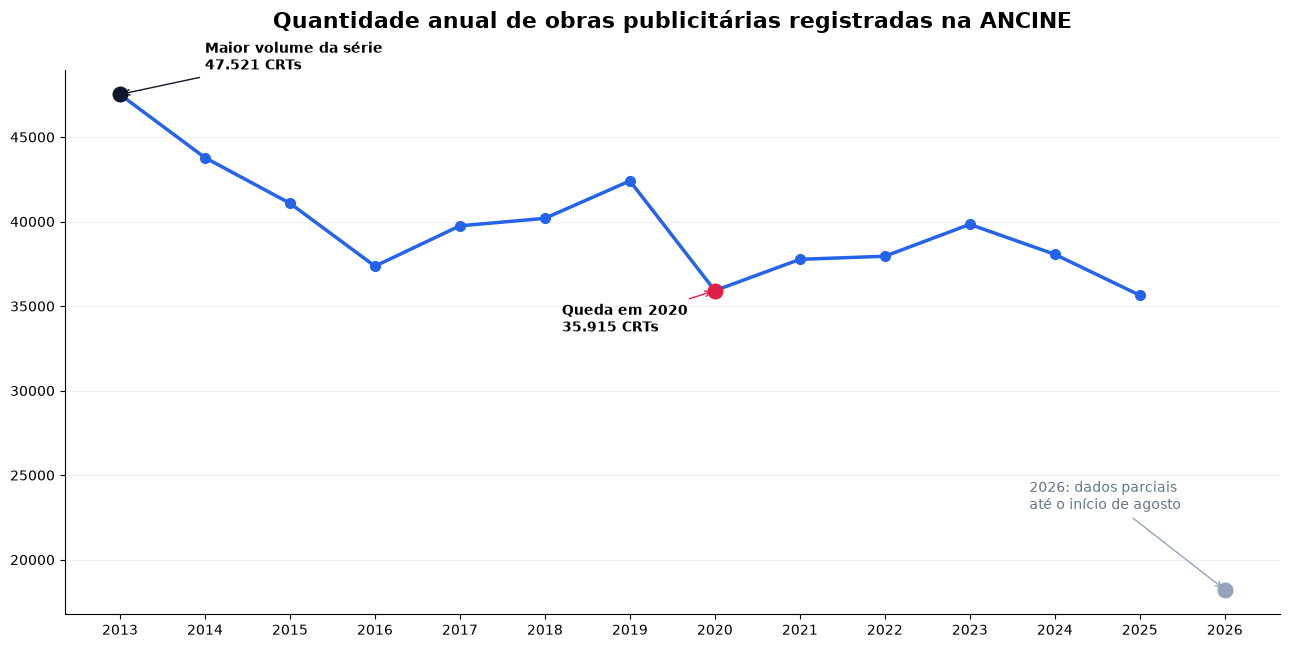

In [55]:
import matplotlib.pyplot as plt

# Separa os anos completos do período parcial de 2026
dados_completos = crts_por_ano[crts_por_ano["ANO_REQUERIMENTO"] <= 2025]
dados_2026 = crts_por_ano[crts_por_ano["ANO_REQUERIMENTO"] == 2026]

fig, ax = plt.subplots(figsize=(13, 7))

# Série histórica comparável
ax.plot(
    dados_completos["ANO_REQUERIMENTO"],
    dados_completos["QUANTIDADE_CRT"],
    marker="o",
    linewidth=2.5,
    markersize=7,
    color="#2563EB"
)

# Destaque do maior volume da série completa
ax.scatter(
    2013,
    47521,
    s=110,
    color="#0F172A",
    zorder=5
)

ax.annotate(
    "Maior volume da série\n47.521 CRTs",
    xy=(2013, 47521),
    xytext=(2014, 49000),
    fontsize=10,
    fontweight="bold",
    arrowprops=dict(
        arrowstyle="->",
        color="#0F172A"
    )
)

# Destaque para 2020
ax.scatter(
    2020,
    35915,
    s=110,
    color="#E11D48",
    zorder=5
)

ax.annotate(
    "Queda em 2020\n35.915 CRTs",
    xy=(2020, 35915),
    xytext=(2018.2, 33500),
    fontsize=10,
    fontweight="bold",
    arrowprops=dict(
        arrowstyle="->",
        color="#E11D48"
    )
)

# 2026 aparece separado por ser um período parcial
ax.scatter(
    dados_2026["ANO_REQUERIMENTO"],
    dados_2026["QUANTIDADE_CRT"],
    s=110,
    color="#94A3B8",
    zorder=5
)

ax.annotate(
    "2026: dados parciais\naté o início de agosto",
    xy=(2026, 18229),
    xytext=(2023.7, 23000),
    fontsize=10,
    color="#64748B",
    arrowprops=dict(
        arrowstyle="->",
        color="#94A3B8"
    )
)

ax.set_title(
    "Quantidade anual de obras publicitárias registradas na ANCINE",
    fontsize=16,
    fontweight="bold",
    loc="center",
    pad=30
)


ax.set_xlabel("")
ax.set_ylabel("")

ax.set_xticks(crts_por_ano["ANO_REQUERIMENTO"])

ax.grid(
    axis="y",
    alpha=0.2
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

#### Análise

Entre 2013 e 2025, o volume anual de CRTs apresentou oscilações ao longo do período. O maior volume foi registrado em 2013, com 47.521 CRTs, seguido por uma redução até 2016. Entre 2017 e 2019 houve recuperação, com 42.407 registros em 2019.

Em 2020, o volume caiu para 35.915 CRTs, seguido por uma recuperação gradual nos anos seguintes, alcançando 39.836 registros em 2023. Em 2024 e 2025, observa-se nova redução no volume anual de registros.

O ano de 2026 possui dados apenas até o início de agosto e, portanto, representa um período parcial. Seus 18.229 CRTs não devem ser comparados diretamente aos totais dos anos completos.

## 7.2 Distribuição dos registros por segmento de mercado

Nesta análise, é avaliada a distribuição das obras publicitárias registradas entre os diferentes segmentos de mercado informados na base da ANCINE.

Como um mesmo CRT pode estar associado a mais de um registro na base consolidada, a análise utiliza a quantidade de CRTs únicos para evitar a contabilização repetida de uma mesma obra.

In [56]:
segmentos_crt = (
    crt.groupby("SEGMENTO")["CRT"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="QUANTIDADE_CRT")
)

segmentos_crt

,SEGMENTO,QUANTIDADE_CRT
0,RADIODIFUSÃO DE SONS E IMAGENS (TV ABERTA),351161
1,TODOS OS SEGMENTOS DE MERCADO,141515
2,COMUNICAÇÃO ELETRÔNICA DE MASSA POR ASSINATURA...,24657
3,OUTROS MERCADOS,14218
4,SALAS DE EXIBIÇÃO,3547
5,VIDEO DOMÉSTICO,396


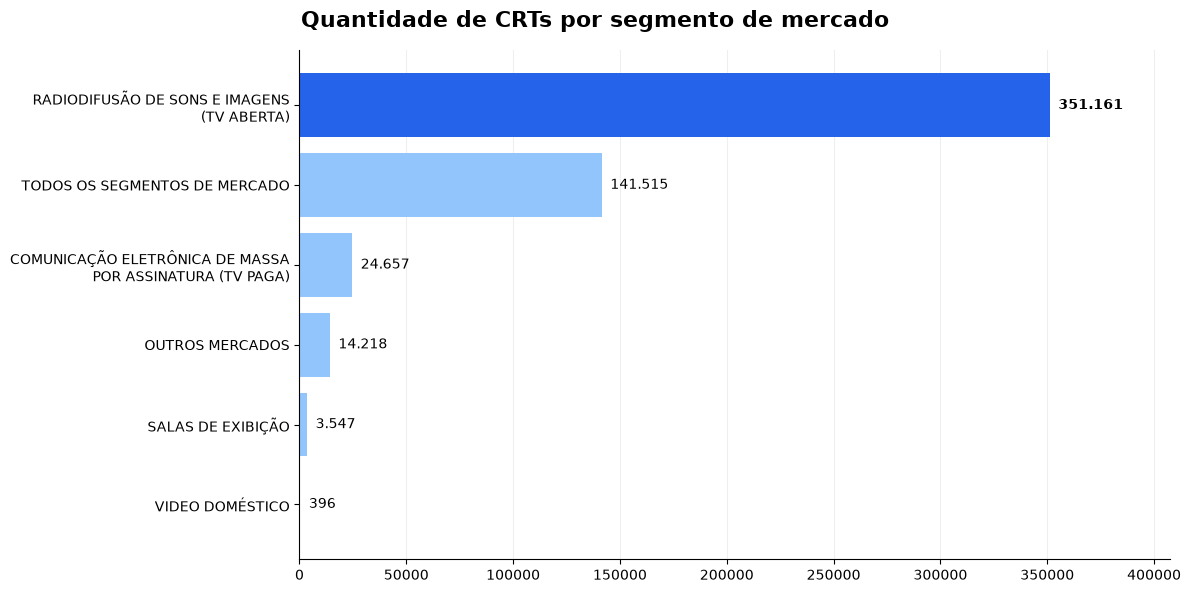

In [61]:
fig, ax = plt.subplots(figsize=(12, 6))

dados_grafico = segmentos_crt.sort_values("QUANTIDADE_CRT")

dados_grafico = dados_grafico.copy()

dados_grafico["SEGMENTO_GRAFICO"] = dados_grafico["SEGMENTO"].replace({
    "RADIODIFUSÃO DE SONS E IMAGENS (TV ABERTA)":
    "RADIODIFUSÃO DE SONS E IMAGENS\n(TV ABERTA)",

    "COMUNICAÇÃO ELETRÔNICA DE MASSA POR ASSINATURA (TV PAGA)":
    "COMUNICAÇÃO ELETRÔNICA DE MASSA\nPOR ASSINATURA (TV PAGA)"
})

cores = [
    "#2563EB" if segmento == "RADIODIFUSÃO DE SONS E IMAGENS (TV ABERTA)"
    else "#93C5FD"
    for segmento in dados_grafico["SEGMENTO"]
]

bars = ax.barh(
    dados_grafico["SEGMENTO_GRAFICO"],
    dados_grafico["QUANTIDADE_CRT"],
    color=cores
)

fig.suptitle(
    "Quantidade de CRTs por segmento de mercado",
    fontsize=16,
    fontweight="bold",
    x=0.5,
    y=0.98,
    ha="center"
)

ax.set_xlabel("")
ax.set_ylabel("")


for bar in bars:
    valor = int(bar.get_width())

    ax.text(
        valor + 4000,
        bar.get_y() + bar.get_height() / 2,
        f"{valor:,.0f}".replace(",", "."),
        va="center",
        fontsize=10,
        fontweight="bold" if valor == 351161 else "normal"
    )

ax.grid(
    axis="x",
    alpha=0.2
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


ax.set_xlim(0, dados_grafico["QUANTIDADE_CRT"].max() * 1.16)

plt.tight_layout()
plt.show()

In [104]:
composicao_segmentos = segmentos_crt.copy()

composicao_segmentos["PERCENTUAL"] = (
    composicao_segmentos["QUANTIDADE_CRT"]
    / composicao_segmentos["QUANTIDADE_CRT"].sum()
    * 100
)

composicao_segmentos

,SEGMENTO,QUANTIDADE_CRT,PERCENTUAL
0,RADIODIFUSÃO DE SONS E IMAGENS (TV ABERTA),351161,65.577019
1,TODOS OS SEGMENTOS DE MERCADO,141515,26.427000
2,COMUNICAÇÃO ELETRÔNICA DE MASSA POR ASSINATURA...,24657,4.604533
3,OUTROS MERCADOS,14218,2.655118
4,SALAS DE EXIBIÇÃO,3547,0.662379
5,VIDEO DOMÉSTICO,396,0.073950


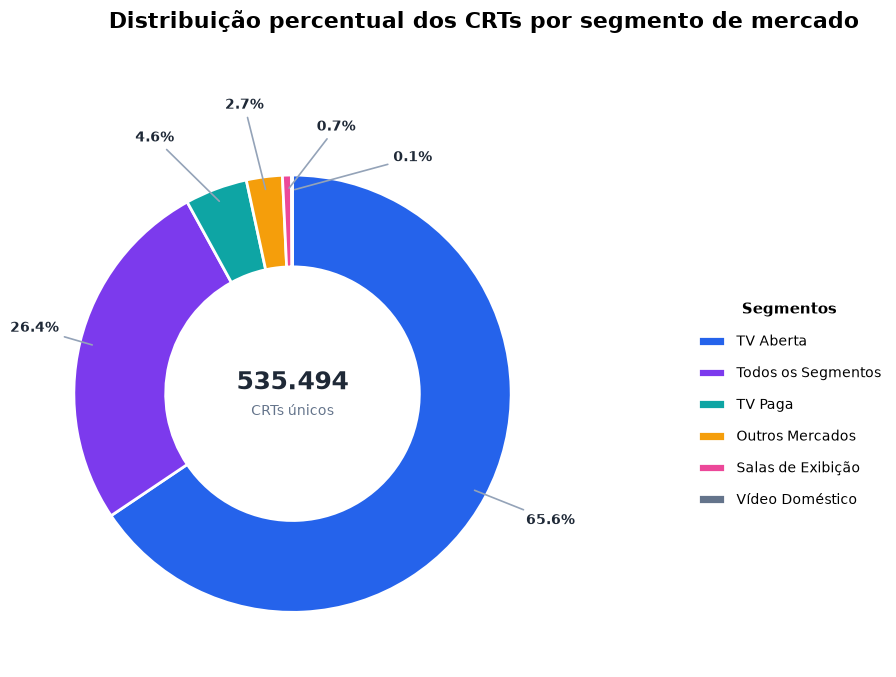

In [111]:
dados_rosca = composicao_segmentos.copy()

nomes_segmentos_rosca = {
    "RADIODIFUSÃO DE SONS E IMAGENS (TV ABERTA)": "TV Aberta",
    "TODOS OS SEGMENTOS DE MERCADO": "Todos os Segmentos",
    "COMUNICAÇÃO ELETRÔNICA DE MASSA POR ASSINATURA (TV PAGA)": "TV Paga",
    "OUTROS MERCADOS": "Outros Mercados",
    "SALAS DE EXIBIÇÃO": "Salas de Exibição",
    "VIDEO DOMÉSTICO": "Vídeo Doméstico"
}

dados_rosca["SEGMENTO_GRAFICO"] = (
    dados_rosca["SEGMENTO"].replace(nomes_segmentos_rosca)
)

cores = [
    "#2563EB",  # Azul
    "#7C3AED",  # Roxo
    "#0EA5A4",  # Verde-azulado
    "#F59E0B",  # Âmbar
    "#EC4899",  # Rosa
    "#64748B"   # Cinza azulado
]

fig, ax = plt.subplots(figsize=(11, 7))

wedges, _ = ax.pie(
    dados_rosca["QUANTIDADE_CRT"],
    labels=None,
    colors=cores,
    startangle=90,
    counterclock=False,
    wedgeprops={
        "width": 0.42,
        "edgecolor": "white",
        "linewidth": 2
    }
)

# Posições organizadas dos percentuais
posicoes_percentuais = [
    (1.18, -0.58),   # 65,6% - TV Aberta
    (-1.18, 0.30),   # 26,4% - Todos os Segmentos
    (-0.63, 1.17),   # 4,6% - TV Paga
    (-0.22, 1.32),   # 2,7% - Outros Mercados
    (0.20, 1.22),    # 0,7% - Salas de Exibição
    (0.55, 1.08)     # 0,1% - Vídeo Doméstico
]

for wedge, percentual, posicao in zip(
    wedges,
    dados_rosca["PERCENTUAL"],
    posicoes_percentuais
):
    angulo = (wedge.theta1 + wedge.theta2) / 2

    x = np.cos(np.deg2rad(angulo))
    y = np.sin(np.deg2rad(angulo))

    ax.annotate(
        f"{percentual:.1f}%",
        xy=(0.93 * x, 0.93 * y),
        xytext=posicao,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#1F2937",
        arrowprops={
            "arrowstyle": "-",
            "color": "#94A3B8",
            "lw": 1.2,
            "connectionstyle": "arc3,rad=0"
        }
    )

# Total de CRTs no centro
ax.text(
    0,
    0.05,
    f"{dados_rosca['QUANTIDADE_CRT'].sum():,.0f}".replace(",", "."),
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold",
    color="#1F2937"
)

ax.text(
    0,
    -0.08,
    "CRTs únicos",
    ha="center",
    va="center",
    fontsize=10,
    color="#64748B"
)

# Legenda
legenda = ax.legend(
    wedges,
    dados_rosca["SEGMENTO_GRAFICO"],
    title="Segmentos",
    title_fontsize=11,
    fontsize=10,
    loc="center left",
    bbox_to_anchor=(1.18, 0.48),
    frameon=False,
    labelspacing=1.25,
    borderaxespad=2
)

legenda.get_title().set_fontweight("bold")

# Título
fig.suptitle(
    "Distribuição percentual dos CRTs por segmento de mercado",
    fontsize=16,
    fontweight="bold",
    x=0.5,
    y=0.96,
    ha="center"
)

ax.set_aspect("equal")

plt.tight_layout(rect=[0, 0, 0.80, 0.91])
plt.show()

#### Análise

A distribuição dos CRTs por segmento de mercado apresenta forte concentração em TV Aberta, com 351.161 CRTs únicos, correspondendo a aproximadamente 65,6% do total analisado.

A categoria "Todos os Segmentos de Mercado" aparece em seguida, com 141.515 CRTs, representando 26,4% do total. A TV Paga possui 24.657 CRTs (4,6%), enquanto Outros Mercados reúne 14.218 registros (2,7%). Salas de Exibição e Vídeo Doméstico apresentam participações inferiores a 1%.

Os dois gráficos apresentam perspectivas complementares sobre a mesma distribuição: o gráfico de barras permite comparar as quantidades absolutas de CRTs entre os segmentos, enquanto o gráfico de rosca evidencia a participação percentual de cada categoria no total de 535.494 CRTs únicos.

Os resultados mostram, portanto, uma concentração expressiva dos registros na categoria TV Aberta, que sozinha representa quase dois terços dos CRTs analisados.

## 7.3 Distribuição por tipo de publicidade

Nesta análise, é avaliada a distribuição das obras publicitárias de acordo com o tipo de publicidade informado nos registros de CRT.

In [62]:
tipos_publicidade = (
    crt.groupby("TIPO_PUBLICIDADE")["CRT"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="QUANTIDADE_CRT")
)

tipos_publicidade

,TIPO_PUBLICIDADE,QUANTIDADE_CRT
0,COMUM,515703
1,TELEVENDA / INFOMERCIAL,11960
2,CARÁTER BENEFICENTE / FILANTRÓPICO,7752
3,PERÍODO DE 24HS INSERIDO EM CANAL TELEVENDA / ...,79


In [66]:
dados_tipo = tipos_publicidade.sort_values("QUANTIDADE_CRT").copy()

dados_tipo["TIPO_GRAFICO"] = dados_tipo["TIPO_PUBLICIDADE"].replace({
    "CARÁTER BENEFICENTE / FILANTRÓPICO":
    "CARÁTER BENEFICENTE /\nFILANTRÓPICO",

    "PERÍODO DE 24HS INSERIDO EM CANAL TELEVENDA / INFOMERCIAL":
    "PERÍODO DE 24HS INSERIDO EM CANAL\nTELEVENDA / INFOMERCIAL"
})

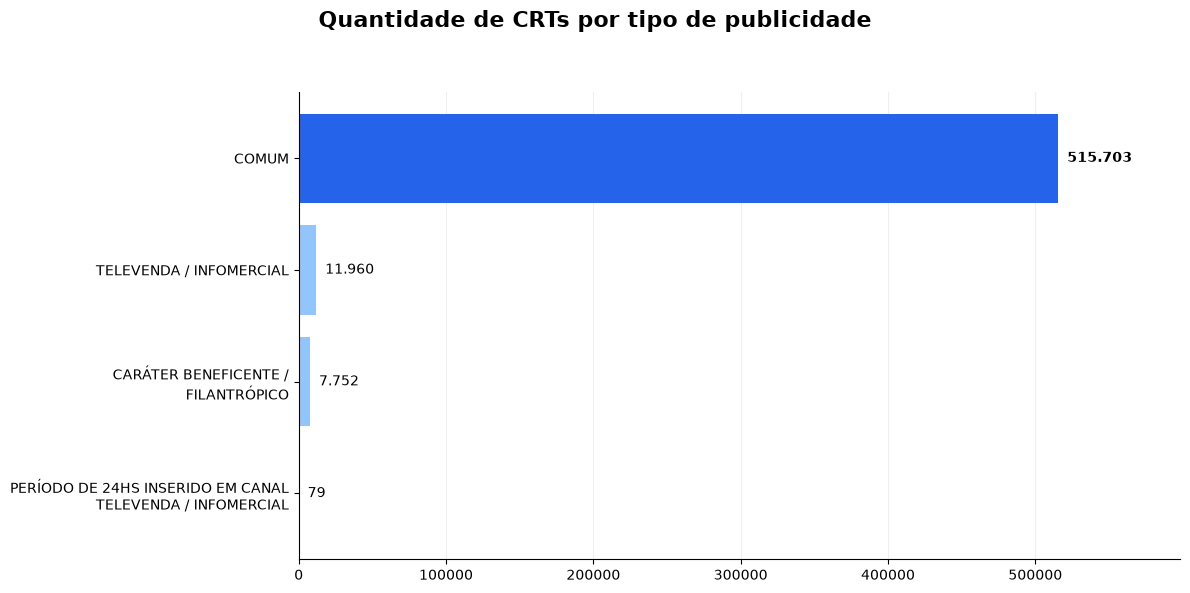

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))


cores = [
    "#2563EB" if tipo == "COMUM"
    else "#93C5FD"
    for tipo in dados_tipo["TIPO_PUBLICIDADE"]
]

bars = ax.barh(
    dados_tipo["TIPO_GRAFICO"],
    dados_tipo["QUANTIDADE_CRT"],
    color=cores
)


fig.suptitle(
    "Quantidade de CRTs por tipo de publicidade",
    fontsize=16,
    fontweight="bold",
    x=0.5,
    y=0.98,
    ha="center"
)

ax.set_xlabel("")
ax.set_ylabel("")


for bar in bars:
    valor = int(bar.get_width())

    ax.text(
        valor + 6000,
        bar.get_y() + bar.get_height() / 2,
        f"{valor:,.0f}".replace(",", "."),
        va="center",
        fontsize=10,
        fontweight="bold" if valor == 515703 else "normal"
    )


ax.grid(
    axis="x",
    alpha=0.2
)

ax.set_axisbelow(True)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


ax.set_xlim(
    0,
    dados_tipo["QUANTIDADE_CRT"].max() * 1.16
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### Análise

A categoria "Comum" concentra a maior parte das obras publicitárias registradas, com 515.703 CRTs, apresentando um volume muito superior ao das demais classificações.

No contexto desta base, "Comum" corresponde à classificação geral das obras publicitárias que não estão enquadradas nas categorias específicas apresentadas separadamente, como Televenda / Infomercial, Caráter Beneficente / Filantrópico e Período de 24 horas inserido em canal de Televenda / Infomercial.

Entre essas categorias específicas, Televenda / Infomercial apresenta 11.960 CRTs, enquanto as obras de Caráter Beneficente / Filantrópico somam 7.752 registros. A categoria Período de 24 horas inserido em canal de Televenda / Infomercial possui apenas 79 CRTs.

A distribuição demonstra, portanto, uma forte concentração dos registros na categoria "Comum", enquanto os demais tipos de publicidade representam parcelas consideravelmente menores da base.

## 7.4 Distribuição da duração das obras publicitárias

Nesta análise, é investigada a duração das obras publicitárias registradas na ANCINE. Para facilitar a interpretação dos valores, a duração originalmente registrada em segundos é convertida para minutos.

Os registros com duração igual a zero são desconsiderados especificamente nesta análise, conforme identificado durante a etapa de tratamento dos dados. Os demais valores são preservados, incluindo durações elevadas que foram previamente verificadas na base.

In [ ]:

crt["DURACAO_MINUTOS"] = crt["DURACAO_SEGUNDOS"] / 60


duracao_valida = crt.loc[
    crt["DURACAO_SEGUNDOS"] > 0,
    "DURACAO_MINUTOS"
]

estatisticas_duracao = duracao_valida.describe()

estatisticas_duracao

count    560268.000000
mean          2.098392
std          43.288094
min           0.016667
25%           0.250000
50%           0.500000
75%           0.500000
max        1440.000000
Name: DURACAO_MINUTOS, dtype: float64

In [69]:
faixas_duracao = pd.Series({
    "Até 30 segundos": (duracao_valida <= 0.5).sum(),
    "Até 1 minuto": (duracao_valida <= 1).sum(),
    "Até 5 minutos": (duracao_valida <= 5).sum(),
    "Até 10 minutos": (duracao_valida <= 10).sum(),
    "Acima de 10 minutos": (duracao_valida > 10).sum()
})

percentuais_duracao = (
    faixas_duracao / len(duracao_valida) * 100
).round(2)

pd.DataFrame({
    "QUANTIDADE": faixas_duracao,
    "PERCENTUAL": percentuais_duracao
})

,QUANTIDADE,PERCENTUAL
Até 30 segundos,483351,86.27
Até 1 minuto,542092,96.76
Até 5 minutos,555521,99.15
Até 10 minutos,556056,99.25
Acima de 10 minutos,4212,0.75


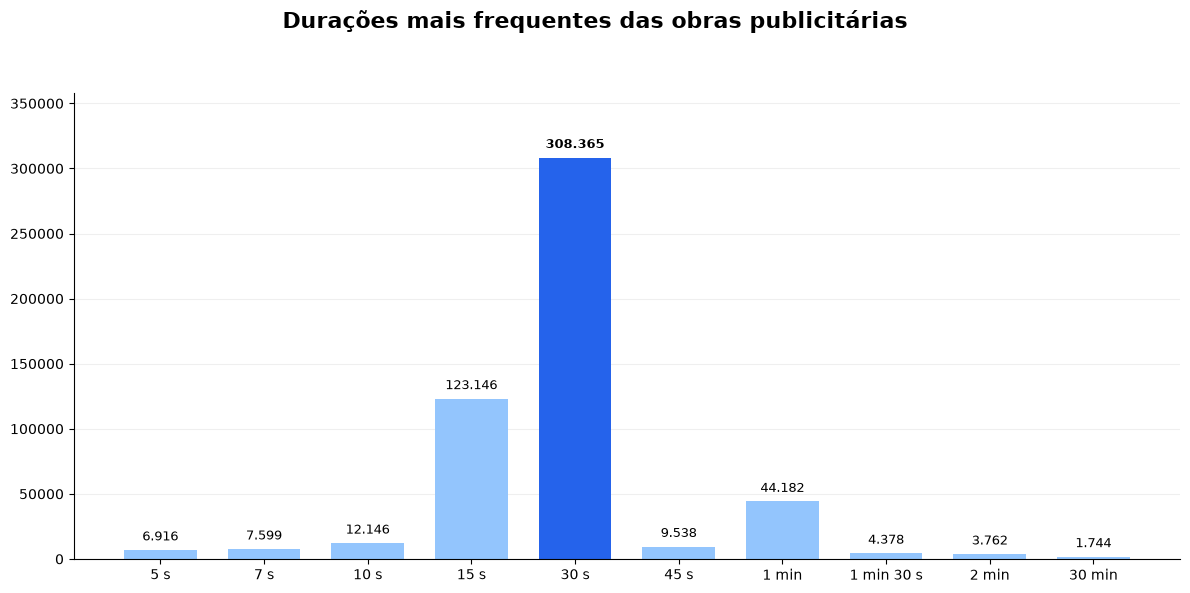

In [73]:
top_duracoes = duracoes_frequentes.head(10).copy()

top_duracoes = top_duracoes.sort_values("DURACAO_SEGUNDOS")


def formatar_duracao(segundos):
    if segundos < 60:
        return f"{int(segundos)} s"

    if segundos % 60 == 0:
        return f"{int(segundos / 60)} min"

    minutos = int(segundos // 60)
    segundos_restantes = int(segundos % 60)

    return f"{minutos} min {segundos_restantes} s"


top_duracoes["DURACAO_GRAFICO"] = (
    top_duracoes["DURACAO_SEGUNDOS"].apply(formatar_duracao)
)

fig, ax = plt.subplots(figsize=(12, 6))


cores = [
    "#2563EB" if duracao == 30
    else "#93C5FD"
    for duracao in top_duracoes["DURACAO_SEGUNDOS"]
]

bars = ax.bar(
    top_duracoes["DURACAO_GRAFICO"],
    top_duracoes["QUANTIDADE_CRT"],
    color=cores,
    width=0.7
)

fig.suptitle(
    "Durações mais frequentes das obras publicitárias",
    fontsize=16,
    fontweight="bold",
    x=0.5,
    y=0.98,
    ha="center"
)

ax.set_xlabel("")
ax.set_ylabel("")


for bar, duracao in zip(bars, top_duracoes["DURACAO_SEGUNDOS"]):
    valor = int(bar.get_height())

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        valor + 5000,
        f"{valor:,.0f}".replace(",", "."),
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold" if duracao == 30 else "normal"
    )

ax.grid(
    axis="y",
    alpha=0.2
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_ylim(
    0,
    top_duracoes["QUANTIDADE_CRT"].max() * 1.16
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


#### Análise

As durações das obras publicitárias apresentam forte concentração em formatos curtos. Entre as durações mais frequentes, 30 segundos se destaca com 308.365 CRTs, seguida por 15 segundos, com 123.146, e 1 minuto, com 44.182 registros.

Essa concentração também é observada nas estatísticas da distribuição: 86,27% dos registros com duração válida possuem até 30 segundos e 96,76% possuem até 1 minuto. A mediana é de 30 segundos, indicando que metade dos registros apresenta duração igual ou inferior a esse valor.

A duração média, por outro lado, é de aproximadamente 2,10 minutos, consideravelmente superior à mediana. Essa diferença ocorre devido à presença de obras com durações muito maiores, que elevam a média. A base contém registros de até 1.440 minutos (24 horas), previamente verificados e mantidos por apresentarem informações compatíveis com formatos publicitários de longa duração.

Dessa forma, a mediana representa melhor a duração típica das obras registradas do que a média, devido à distribuição assimétrica e à presença de valores extremos.

## 7.5 Atividades econômicas dos agentes relacionados às obras publicitárias

Nesta análise, os registros de obras publicitárias são relacionados às bases de agentes econômicos e de atividades econômicas da ANCINE.

O objetivo é identificar quais atividades econômicas aparecem com maior frequência entre os agentes relacionados aos registros de CRT que possuem correspondência entre as bases.

In [74]:
print("CRT:")
print([col for col in crt.columns if "CNPJ" in col])

print("\nAGENTES:")
print([col for col in agentes.columns if "CNPJ" in col])

print("\nATIVIDADES:")
print([col for col in atividades.columns if "CNPJ" in col])

CRT:
['CNPJ_AGENCIA', 'CNPJ_ANUNCIANTE', 'CNPJ_REQUERENTE']

AGENTES:
['CNPJ']

ATIVIDADES:
['CNPJ']


In [75]:
def padronizar_cnpj(valor):
    valor = str(valor)

    # Mantém apenas os números
    cnpj = "".join(caractere for caractere in valor if caractere.isdigit())

    # Um CNPJ válido para o cruzamento deve possuir 14 dígitos
    if len(cnpj) == 14:
        return cnpj

    return pd.NA


crt["CNPJ_REQUERENTE_LIMPO"] = crt["CNPJ_REQUERENTE"].apply(padronizar_cnpj)
agentes["CNPJ_LIMPO"] = agentes["CNPJ"].apply(padronizar_cnpj)
atividades["CNPJ_LIMPO"] = atividades["CNPJ"].apply(padronizar_cnpj)

In [76]:
cnpjs_agentes = set(
    agentes["CNPJ_LIMPO"].dropna()
)

correspondencias_crt = crt["CNPJ_REQUERENTE_LIMPO"].isin(cnpjs_agentes)

print(
    "CRTs com CNPJ válido:",
    crt["CNPJ_REQUERENTE_LIMPO"].notna().sum()
)

print(
    "Registros encontrados em Agentes:",
    correspondencias_crt.sum()
)

print(
    "Cobertura:",
    round(
        correspondencias_crt.sum()
        / crt["CNPJ_REQUERENTE_LIMPO"].notna().sum()
        * 100,
        2
    ),
    "%"
)

CRTs com CNPJ válido: 548964
Registros encontrados em Agentes: 398210
Cobertura: 72.54 %


In [77]:
crt_agentes = crt.merge(
    agentes,
    left_on="CNPJ_REQUERENTE_LIMPO",
    right_on="CNPJ_LIMPO",
    how="inner",
    suffixes=("_CRT", "_AGENTE")
)

print("Linhas após CRT + Agentes:", len(crt_agentes))
print("CRTs únicos relacionados:", crt_agentes["CRT"].nunique())

Linhas após CRT + Agentes: 398210
CRTs únicos relacionados: 377871


In [78]:
crt_agentes_atividades = crt_agentes.merge(
    atividades,
    left_on="CNPJ_LIMPO",
    right_on="CNPJ_LIMPO",
    how="inner",
    suffixes=("", "_ATIVIDADE")
)

print("Linhas após CRT + Agentes + Atividades:", len(crt_agentes_atividades))
print("CRTs únicos relacionados:", crt_agentes_atividades["CRT"].nunique())

Linhas após CRT + Agentes + Atividades: 2341538
CRTs únicos relacionados: 377871


In [79]:
print([
    coluna
    for coluna in crt_agentes_atividades.columns
    if "ATIV" in coluna.upper()
    or "CLASS" in coluna.upper()
])

['CLASSIFICACAO_OBRA', 'CLASSIFICACAO_AGENTE_ECONOMICO', 'REGISTRO_ANCINE_ATIVIDADE', 'RAZAO_SOCIAL_ATIVIDADE', 'CNPJ_ATIVIDADE', 'CLASSIFICACAO_ATIVIDADE', 'ATIVIDADE_ECONOMICA']


In [80]:
print("Classificações de atividade:")
print(
    crt_agentes_atividades["CLASSIFICACAO_ATIVIDADE"]
    .value_counts(dropna=False)
)

print("\nAtividades econômicas ausentes:")
print(
    crt_agentes_atividades["ATIVIDADE_ECONOMICA"]
    .isna()
    .sum()
)

print("\nQuantidade de atividades econômicas distintas:")
print(
    crt_agentes_atividades["ATIVIDADE_ECONOMICA"]
    .nunique()
)

Classificações de atividade:
CLASSIFICACAO_ATIVIDADE
SECUNDARIA    1884837
PRINCIPAL      456701
Name: count, dtype: int64

Atividades econômicas ausentes:
0

Quantidade de atividades econômicas distintas:
421


In [81]:
resumo_classificacao = (
    crt_agentes_atividades
    .groupby("CLASSIFICACAO_ATIVIDADE")
    .agg(
        QUANTIDADE_LINHAS=("CRT", "size"),
        CRTS_UNICOS=("CRT", "nunique"),
        ATIVIDADES_DISTINTAS=("ATIVIDADE_ECONOMICA", "nunique")
    )
)

resumo_classificacao

,QUANTIDADE_LINHAS,CRTS_UNICOS,ATIVIDADES_DISTINTAS
CLASSIFICACAO_ATIVIDADE,,,
PRINCIPAL,456701,377871,131
SECUNDARIA,1884837,347444,413


In [82]:
atividades_principais = (
    crt_agentes_atividades[
        crt_agentes_atividades["CLASSIFICACAO_ATIVIDADE"] == "PRINCIPAL"
    ]
    .groupby("ATIVIDADE_ECONOMICA")["CRT"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="QUANTIDADE_CRT")
)

atividades_principais.head(15)

,ATIVIDADE_ECONOMICA,QUANTIDADE_CRT
0,"Atividades de produção cinematográfica, de víd...",112093
1,Produção de filmes para publicidade,103889
2,"Atividades de pós-produção cinematográfica, de...",40277
3,Agências de publicidade,28595
4,Atividades de televisão aberta,17792
5,Filmagem de festas e eventos,12911
6,Comércio varejista de artigos fotográficos e p...,12137
7,Estúdios cinematográficos,8223
8,"Tratamento de dados, provedores de serviços de...",6405
9,"Agenciamento de espaços para publicidade, exce...",5435


In [84]:
for indice, linha in top_atividades.iterrows():
    print(
        f"{indice + 1}. {linha['ATIVIDADE_ECONOMICA']} "
        f"— {linha['QUANTIDADE_CRT']:,} CRTs"
    )

1. Atividades de produção cinematográfica, de vídeos e de programas de televisão não especificadas anteriormente — 112,093 CRTs
2. Produção de filmes para publicidade — 103,889 CRTs
3. Atividades de pós-produção cinematográfica, de vídeos e de programas de televisão não especificadas anteriormente — 40,277 CRTs
4. Agências de publicidade — 28,595 CRTs
5. Atividades de televisão aberta — 17,792 CRTs
6. Filmagem de festas e eventos — 12,911 CRTs
7. Comércio varejista de artigos fotográficos e para filmagem — 12,137 CRTs
8. Estúdios cinematográficos — 8,223 CRTs
9. Tratamento de dados, provedores de serviços de aplicação e serviços de hospedagem na internet — 6,405 CRTs
10. Agenciamento de espaços para publicidade, exceto em veículos de comunicação — 5,435 CRTs


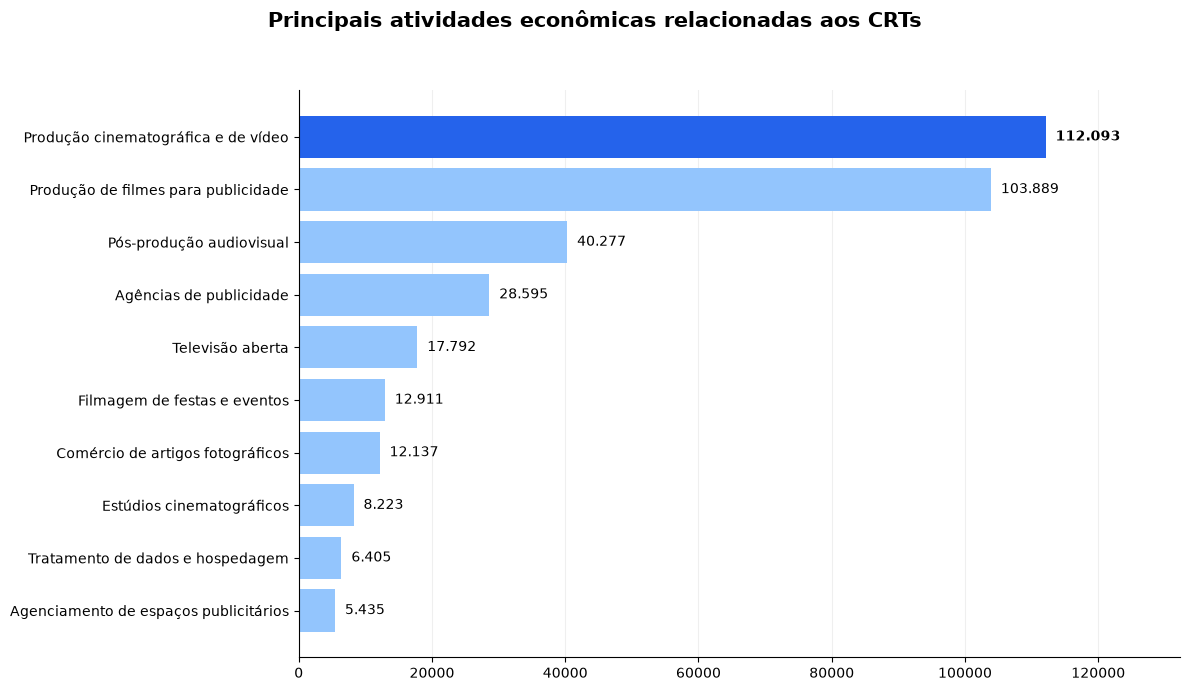

In [87]:
import matplotlib.pyplot as plt

dados_atividades = top_atividades.sort_values("QUANTIDADE_CRT").copy()

dados_atividades["ATIVIDADE_GRAFICO"] = dados_atividades["ATIVIDADE_ECONOMICA"].replace({
    "Atividades de produção cinematográfica, de vídeos e de programas de televisão não especificadas anteriormente":
        "Produção cinematográfica e de vídeo",

    "Produção de filmes para publicidade":
        "Produção de filmes para publicidade",

    "Atividades de pós-produção cinematográfica, de vídeos e de programas de televisão não especificadas anteriormente":
        "Pós-produção audiovisual",

    "Agências de publicidade":
        "Agências de publicidade",

    "Atividades de televisão aberta":
        "Televisão aberta",

    "Filmagem de festas e eventos":
        "Filmagem de festas e eventos",

    "Comércio varejista de artigos fotográficos e para filmagem":
        "Comércio de artigos fotográficos",

    "Estúdios cinematográficos":
        "Estúdios cinematográficos",

    "Tratamento de dados, provedores de serviços de aplicação e serviços de hospedagem na internet":
        "Tratamento de dados e hospedagem",

    "Agenciamento de espaços para publicidade, exceto em veículos de comunicação":
        "Agenciamento de espaços publicitários"
})

cores = [
    "#2563EB" if atividade == "Atividades de produção cinematográfica, de vídeos e de programas de televisão não especificadas anteriormente"
    else "#93C5FD"
    for atividade in dados_atividades["ATIVIDADE_ECONOMICA"]
]

fig, ax = plt.subplots(figsize=(12, 7))

barras = ax.barh(
    dados_atividades["ATIVIDADE_GRAFICO"],
    dados_atividades["QUANTIDADE_CRT"],
    color=cores
)

fig.suptitle(
    "Principais atividades econômicas relacionadas aos CRTs",
    fontsize=15,
    fontweight="bold",
    x=0.5,
    ha="center"
)

ax.set_xlabel("")
ax.set_ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="x",
    alpha=0.2
)

ax.set_axisbelow(True)

ax.set_xlim(
    0,
    dados_atividades["QUANTIDADE_CRT"].max() * 1.18
)

for barra, valor in zip(
    barras,
    dados_atividades["QUANTIDADE_CRT"]
):
    ax.text(
        valor + 1500,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:,.0f}".replace(",", "."),
        va="center",
        fontsize=10,
        fontweight="bold" if valor == dados_atividades["QUANTIDADE_CRT"].max() else "normal"
    )

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

#### Análise

Entre os agentes relacionados aos CRTs, as atividades econômicas principais com maior presença são "Produção cinematográfica e de vídeo", associada a 112.093 CRTs únicos, e "Produção de filmes para publicidade", com 103.889.

Em seguida, aparecem atividades de pós-produção audiovisual, com 40.277 CRTs, e agências de publicidade, com 28.595. As demais atividades apresentam quantidades progressivamente menores, incluindo televisão aberta, filmagem de festas e eventos, comércio de artigos fotográficos e estúdios cinematográficos.

Os resultados mostram que os CRTs relacionados entre as três bases estão concentrados principalmente em agentes cuja atividade econômica principal está ligada à produção audiovisual e à publicidade. A análise considera apenas os 377.871 CRTs únicos que possuem correspondência com a base de agentes e utiliza a atividade classificada como principal na base de atividades econômicas.

## 7.6 Distribuição geográfica dos registros por UF

Nesta análise, é avaliada a distribuição geográfica das obras publicitárias registradas na ANCINE a partir da UF informada para o requerente do CRT.

In [94]:
uf_crt = (
    crt.groupby("UF_REQUERENTE")["CRT"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="QUANTIDADE_CRT")
)

uf_crt

,UF_REQUERENTE,QUANTIDADE_CRT
0,SP,169198
1,PR,57838
2,SC,42824
3,RS,41302
4,MG,38105
5,RJ,33765
6,ES,24312
7,BA,22297
8,GO,16930
9,PE,12531


## 7.7 Relação entre segmento de mercado e tipo de publicidade

Nesta análise, é avaliada a distribuição dos CRTs considerando simultaneamente o segmento de mercado e o tipo de publicidade, permitindo identificar quais combinações apresentam maior concentração de registros.

In [96]:
segmento_tipo = (
    crt.groupby(
        ["SEGMENTO", "TIPO_PUBLICIDADE"]
    )["CRT"]
    .nunique()
    .unstack(fill_value=0)
)

segmento_tipo

TIPO_PUBLICIDADE,CARÁTER BENEFICENTE / FILANTRÓPICO,COMUM,PERÍODO DE 24HS INSERIDO EM CANAL TELEVENDA / INFOMERCIAL,TELEVENDA / INFOMERCIAL
SEGMENTO,,,,
COMUNICAÇÃO ELETRÔNICA DE MASSA POR ASSINATURA (TV PAGA),266,23474,11,906
OUTROS MERCADOS,123,13998,10,87
RADIODIFUSÃO DE SONS E IMAGENS (TV ABERTA),2433,339115,40,9573
SALAS DE EXIBIÇÃO,62,3447,0,38
TODOS OS SEGMENTOS DE MERCADO,4856,135296,17,1346
VIDEO DOMÉSTICO,12,373,1,10


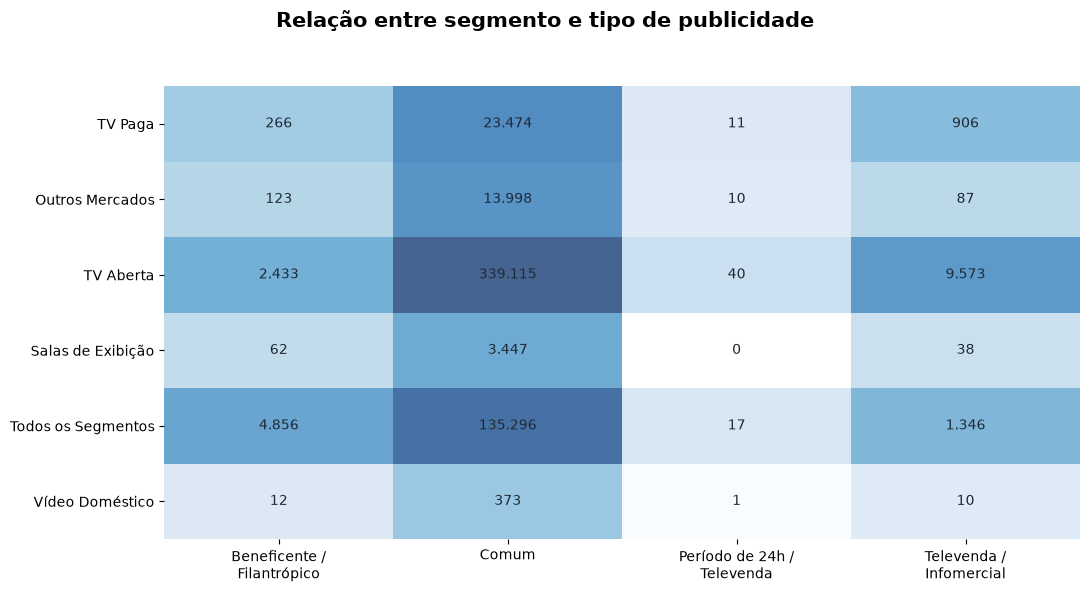

In [101]:
from matplotlib.colors import LogNorm

segmento_tipo_grafico = segmento_tipo.copy()

nomes_segmentos = {
    "COMUNICAÇÃO ELETRÔNICA DE MASSA POR ASSINATURA (TV PAGA)":
        "TV Paga",
    "OUTROS MERCADOS":
        "Outros Mercados",
    "RADIODIFUSÃO DE SONS E IMAGENS (TV ABERTA)":
        "TV Aberta",
    "SALAS DE EXIBIÇÃO":
        "Salas de Exibição",
    "TODOS OS SEGMENTOS DE MERCADO":
        "Todos os Segmentos",
    "VIDEO DOMÉSTICO":
        "Vídeo Doméstico"
}

nomes_tipos = {
    "CARÁTER BENEFICENTE / FILANTRÓPICO":
        "Beneficente /\nFilantrópico",
    "COMUM":
        "Comum",
    "PERÍODO DE 24HS INSERIDO EM CANAL TELEVENDA / INFOMERCIAL":
        "Período de 24h /\nTelevenda",
    "TELEVENDA / INFOMERCIAL":
        "Televenda /\nInfomercial"
}

segmento_tipo_grafico = segmento_tipo_grafico.rename(
    index=nomes_segmentos,
    columns=nomes_tipos
)

valores = segmento_tipo_grafico.values

norm = LogNorm(
    vmin=1,
    vmax=valores.max()
)

fig, ax = plt.subplots(figsize=(11, 6))

imagem = ax.imshow(
    valores,
    cmap="Blues",
    norm=norm,
    aspect="auto",
    alpha=0.75
)

ax.set_xticks(range(len(segmento_tipo_grafico.columns)))
ax.set_xticklabels(segmento_tipo_grafico.columns)

ax.set_yticks(range(len(segmento_tipo_grafico.index)))
ax.set_yticklabels(segmento_tipo_grafico.index)


for i in range(valores.shape[0]):
    for j in range(valores.shape[1]):
        valor = valores[i, j]

        ax.text(
            j,
            i,
            f"{valor:,.0f}".replace(",", "."),
            ha="center",
            va="center",
            fontsize=10,
            color="#1F2937"
        )

fig.suptitle(
    "Relação entre segmento e tipo de publicidade",
    fontsize=15,
    fontweight="bold",
    x=0.5,
    ha="center"
)

ax.set_xlabel("")
ax.set_ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

## 8. Conclusão

A análise exploratória dos dados públicos da ANCINE permitiu identificar características relevantes do mercado publicitário audiovisual brasileiro a partir dos registros de CRT.

Os resultados mostram uma forte concentração dos registros no segmento de TV Aberta, que representa aproximadamente 65,6% dos CRTs analisados. A categoria de publicidade "Comum" também apresenta ampla predominância entre os registros.

Em relação à duração das obras, observa-se uma concentração em formatos curtos, principalmente de 30 e 15 segundos. A análise temporal mostrou variações no volume anual de registros ao longo do período analisado, enquanto a distribuição geográfica evidenciou maior concentração de requerentes em São Paulo.

O cruzamento com as bases de agentes econômicos e atividades econômicas mostrou maior presença de atividades relacionadas à produção audiovisual, produção de filmes para publicidade, pós-produção e agências de publicidade entre os agentes associados aos CRTs.

De forma geral, a análise permitiu explorar o mercado publicitário audiovisual sob diferentes perspectivas, incluindo evolução temporal, segmentos de mercado, tipos de publicidade, duração das obras, localização dos requerentes e atividades econômicas relacionadas.

Como etapa complementar do projeto, os principais indicadores e resultados desta análise serão apresentados em um dashboard interativo desenvolvido no Looker Studio, permitindo a exploração visual dos dados por meio de gráficos, indicadores e filtros.